In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
def build_window_dataset(df, feature_cols, target_cols, protein_col="ProteinID", window_size=11):
    half = window_size // 2
    X_list, y_list = [], []

    for _, g in df.groupby(protein_col):
        g = g.sort_values("ResidueIndex").reset_index(drop=True)

        feats = g[feature_cols].values
        targets = g[target_cols].values

        pad = np.zeros((half, feats.shape[1]), dtype=np.float32)
        feats_padded = np.vstack([pad, feats, pad])

        for i in range(len(g)):
            window = feats_padded[i:i + window_size].reshape(-1)
            X_list.append(window)
            y_list.append(targets[i])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return X, y

In [3]:
feature_cols = [f"Evo{i}" for i in range(1, 22)] + [
    "AA_A","AA_C","AA_D","AA_E","AA_F","AA_G","AA_H","AA_I","AA_K","AA_L",
    "AA_M","AA_N","AA_P","AA_Q","AA_R","AA_S","AA_T","AA_V","AA_W","AA_Y"
]

target_cols = ["dist_i1", "dist_i2", "dist_i4", "dist_i8"]

print("Feature count:", len(feature_cols))
print("Target count:", len(target_cols))

Feature count: 41
Target count: 4


In [4]:
train_df = pd.read_parquet("../data/Multi_distance_edits/train_dist.parquet")
val_df = pd.read_parquet("../data/Multi_distance_edits/val_dist.parquet")
test_df = pd.read_parquet("../data/Multi_distance_edits/test_dist.parquet")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (3337092, 55)
Val: (47602, 55)
Test: (24466, 55)


Windows sizes to test 

In [5]:
window_sizes = [5,11,15,21]

Run ablation on these window sizes 

In [6]:
ablation_results = []

for window_size in window_sizes:
    print(f"\n===== Window Size: {window_size} =====")

    X_train, y_train = build_window_dataset(train_df, feature_cols, target_cols, window_size=window_size)
    X_val, y_val = build_window_dataset(val_df, feature_cols, target_cols, window_size=window_size)
    X_test, y_test = build_window_dataset(test_df, feature_cols, target_cols, window_size=window_size)

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

    preds_all = []

    for t in range(y_train.shape[1]):

        model = XGBRegressor(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,

            subsample=0.8,
            colsample_bytree=0.8,

            tree_method="hist",
            device="cuda",          # GPU ENABLED
            predictor="gpu_predictor",

            max_bin=256,

            random_state=42,
            verbosity=1
        )

        model.fit(X_train, y_train[:, t])

        pred_t = model.predict(X_test)
        preds_all.append(pred_t)

    preds = np.column_stack(preds_all)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    ablation_results.append({
        "WindowSize": window_size,
        "NumFeatures": X_train.shape[1],
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")


===== Window Size: 5 =====
X_train: (3337092, 205) y_train: (3337092, 4)
X_val: (47602, 205) y_val: (47602, 4)
X_test: (24466, 205) y_test: (24466, 4)


d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [16:58:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\core.py:751: UserWarning: [16:58:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [16:58:54] WARNING: C:\actions-runner\_work\xgbo

RMSE: 745.3353
MAE: 217.6340
R2: 0.5102

===== Window Size: 11 =====
X_train: (3337092, 451) y_train: (3337092, 4)
X_val: (47602, 451) y_val: (47602, 4)
X_test: (24466, 451) y_test: (24466, 4)


d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:01:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:02:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:03:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:04:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are

RMSE: 630.1377
MAE: 176.9840
R2: 0.6297

===== Window Size: 15 =====
X_train: (3337092, 615) y_train: (3337092, 4)
X_val: (47602, 615) y_val: (47602, 4)
X_test: (24466, 615) y_test: (24466, 4)


d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:06:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:08:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are

RMSE: 596.7797
MAE: 166.7432
R2: 0.6529

===== Window Size: 21 =====
X_train: (3337092, 861) y_train: (3337092, 4)
X_val: (47602, 861) y_val: (47602, 4)
X_test: (24466, 861) y_test: (24466, 4)


d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:13:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:17:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\training.py:200: UserWarning: [17:20:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are

RMSE: 577.0703
MAE: 160.6447
R2: 0.6669


In [7]:
ablation_df = pd.DataFrame(ablation_results).sort_values("WindowSize").reset_index(drop=True)
ablation_df

,WindowSize,NumFeatures,RMSE,MAE,R2
0,5,205,745.335327,217.633972,0.510191
1,11,451,630.137733,176.983978,0.629684
2,15,615,596.779744,166.743240,0.652864
3,21,861,577.070295,160.644653,0.666873


In [9]:
ablation_df = pd.DataFrame(ablation_results).sort_values("WindowSize").reset_index(drop=True)
ablation_df.to_csv("window_size_ablation_results.csv", index=False)
print("\nAblation Results:")
ablation_df


Ablation Results:


,WindowSize,NumFeatures,RMSE,MAE,R2
0,5,205,745.335327,217.633972,0.510191
1,11,451,630.137733,176.983978,0.629684
2,15,615,596.779744,166.743240,0.652864
3,21,861,577.070295,160.644653,0.666873


R2 vs window size

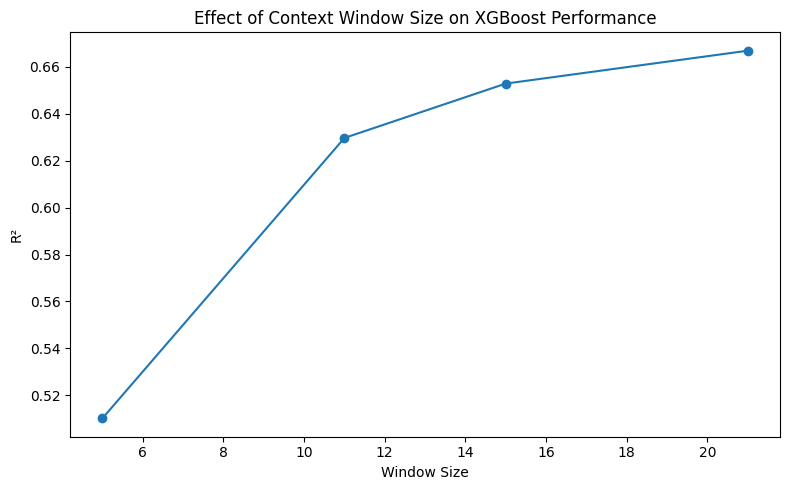

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["WindowSize"], ablation_df["R2"], marker="o")
plt.xlabel("Window Size")
plt.ylabel("R²")
plt.title("Effect of Context Window Size on XGBoost Performance")
plt.tight_layout()
plt.show()

RMSE vs window size

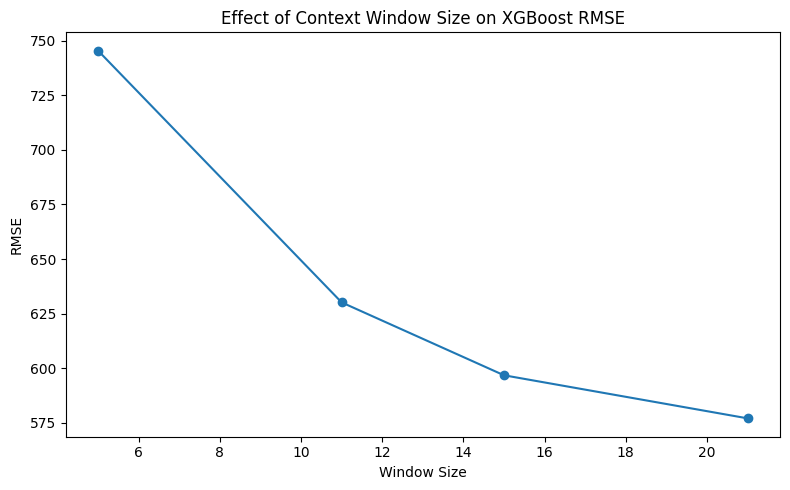

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["WindowSize"], ablation_df["RMSE"], marker="o")
plt.xlabel("Window Size")
plt.ylabel("RMSE")
plt.title("Effect of Context Window Size on XGBoost RMSE")
plt.tight_layout()
plt.show()

In [12]:
best_row = ablation_df.loc[ablation_df["R2"].idxmax()]
print("Best window configuration:")
print(best_row)

Best window configuration:
WindowSize      21.000000
NumFeatures    861.000000
RMSE           577.070295
MAE            160.644653
R2               0.666873
Name: 3, dtype: float64


In [5]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

BEST_WINDOW = 21
target_cols = ["dist_i1", "dist_i2", "dist_i4", "dist_i8"]

X_train_best, y_train_best = build_window_dataset(train_df, feature_cols, target_cols, 21)
X_val_best, y_val_best = build_window_dataset(val_df, feature_cols, target_cols, 21)
X_test_best, y_test_best = build_window_dataset(test_df, feature_cols, target_cols, 21)

print("Train:", X_train_best.shape, y_train_best.shape)
print("Val:", X_val_best.shape, y_val_best.shape)
print("Test:", X_test_best.shape, y_test_best.shape)

NameError: name 'feature_cols' is not defined

In [14]:
final_models = {}
final_test_preds = []

for i, target in enumerate(target_cols):
    print(f"\nTraining final model for {target}")

    model = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    model.fit(X_train_best, y_train_best[:, i])

    pred = model.predict(X_test_best)

    final_models[target] = model
    final_test_preds.append(pred)


Training final model for dist_i1


XGBoostError: [17:31:45] C:\actions-runner\_work\xgboost\xgboost\src\common\io.h:362: bad_malloc: Failed to allocate 2873236212 bytes.

In [ ]:
final_preds = np.column_stack(final_test_preds)

overall_rmse = np.sqrt(mean_squared_error(y_test_best, final_preds))
overall_mae = mean_absolute_error(y_test_best, final_preds)
overall_r2 = r2_score(y_test_best, final_preds)

overall_results = pd.DataFrame([{
    "WindowSize": BEST_WINDOW,
    "RMSE": overall_rmse,
    "MAE": overall_mae,
    "R2": overall_r2
}])

print(overall_results)
overall_results.to_csv("final_overall_results.csv", index=False)